## Titanic Project

Ok lets get started, first project not on Jupyter but we will try to use the notebook of VSC this time, switch things up a little. This youtube guide:
https://www.youtube.com/watch?v=8yZMXCaFshs
gives a good structure on how I should approach

1. Accept the rules & join the competition
2. Download the data
3. Understand the problem
4. EDA (Exploratory Data Analysis)
5. Train, Tune and Ensemble ML models (lmao, ML? Doesn't feel like ML when we will just be doing LDA, QDA or something similar)
6. Upload your prediction as submission and receive accuracy score

Also step 0 lets see if we can get python working here


In [1]:
# Step 0, lets import the regular stuff we will probably need
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize)
print('Done part 1212')

Done part 1212


In [ ]:
# MORE MOUSE BITES
# Ehh, we should really start learning SCIKITLEARN next or whatever its called
# but I think for this project its not horrible to stick with the ISLP resources
# since we ARE straying from the notes now
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import re
print('Done part 2')

Done part 2 asddfsdf


In [3]:
# Ok now lets try and get our hands on the data itself:
Titanic_train = pd.read_csv('titanic_data/train.csv')

Titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Next, we imported the data into excel and did some exploratory data analysis

<img src="images_titanic/EDA summary.png" width="1300">



We write a game plan for how to transform the data:

To do list:

> Drop column Passenger ID

> Use python (regex?) to group up names into Miss., Mrs.,  Master., Mr., and Other.

> Find average age of sex-group average. Sure there will be some correlation now between age and title, but we can just decide to not include Title if need be.

> Add both SibSP and Parch together to get "Family members". Then cluster "Family members" into categories (4?)

> Cabin Number turn into categories using python: Null, A, B, C, D, …

> Embarked assign any without embark to the mode, thats it


In [5]:
# We drop the useless looking column
#Titanic_train.drop(columns='PassengerId')


# Then we use regex to find the different groups, and make a new column. The column we care about is 'Name', we categorize according to cat we found and what google says they mean
conditions_name = [
    Titanic_train['Name'].str.contains(r'Master') 
    , Titanic_train['Name'].str.contains(r'Mrs.') | Titanic_train['Name'].str.contains(r'Mme.')# Married woman Mme
    , Titanic_train['Name'].str.contains(r'Mr.') # Mr.
    , Titanic_train['Name'].str.contains(r'Miss.') | Titanic_train['Name'].str.contains(r'Mlle.') # Girl or unmarried woman, Unmarried
]

choices_name = ['Master'
                , 'Mrs/Mme'
                , 'Mr'
                , 'Miss/Mlle']

Titanic_train['Title'] = np.select(conditions_name, choices_name, default = 'Other')

# We review the value counts, Other is a BIT suspect in terms of being too small a category, but since we are using this for age estimation as opposed to category, I think this is ok
Titanic_train['Title'].value_counts()

Title
Mr           518
Miss/Mlle    181
Mrs/Mme      130
Master        40
Other         22
Name: count, dtype: int64

In [6]:
# Now we need to make estimations of the age. So we make a different DF of train, where the age is not null
# #Titanic_train['Sex'].value_counts()

# We make it a copy so we can edit it.
Titanic_train_Age_Est = Titanic_train.copy()

#Titanic_train.loc[Titanic_train['Age'].notnull()]
#Titanic_train.loc[lambda.df:]

# Pseudo code:
print('The median age was ' + str(Titanic_train_Age_Est['Age'].median()))

# # This was my idea:
# Master_avg_age      = np.median(Titanic_train_Age_Est.loc[lambda df: (df['Title'] == 'Master') & (df['Age'] != None), ['Age']])
# Miss_Mlle_avg_age   = np.median(Titanic_train_Age_Est.loc[lambda df: (df['Title'] == 'Miss/Mlle') & (df['Age'] != None), ['Age']])
# Mr_avg_age          = np.median(Titanic_train_Age_Est.loc[lambda df: (df['Title'] == 'Mr') & (df['Age'] != None), ['Age']])
# Mrs_Mme_avg_age     = np.median(Titanic_train_Age_Est.loc[lambda df: (df['Title'] == 'Mrs/Mme') & (df['Age'] != None), ['Age']])
# Other_avg_age       = np.median(Titanic_train_Age_Est.loc[lambda df: (df['Title'] == 'Other') & (df['Age'] != None), ['Age']])

# for row in Titanic_train_Age_Est:
#     if Titanic_train_Age_Est['Age'][row] is not null:
#         break
#     else:
#         if Titanic_train_Age_Est['Title'][row] == 'Master':
#             Titanic_train_Age_Est['Age'][row] = Master_avg_age
            
#         elif Titanic_train_Age_Est['Title'][row] == 'Miss/Mlle':
#             Titanic_train_Age_Est['Age'][row] = Miss_Mlle_avg_age
            
#         elif Titanic_train_Age_Est['Title'][row] == 'Mr':
#             Titanic_train_Age_Est['Age'][row] = Mr_avg_age
            
#         elif Titanic_train_Age_Est['Title'][row] == 'Mrs/Mme':
#             Titanic_train_Age_Est['Age'][row] = Mrs_Mme_avg_age
        
#         else: 
#             Titanic_train_Age_Est['Age'][row] == Other_avg_age

## But AI just did it in one line. Wowzers, will need to try and copy and reuse this later (Gemini, my thanks to you):

# Gemini code:
Titanic_train_Age_Est['Age'] = Titanic_train_Age_Est['Age'].fillna(
    Titanic_train_Age_Est.groupby('Title')['Age'].transform('median')
)

print('The median age has changed to be ' + str(Titanic_train_Age_Est['Age'].median()))

The median age was 28.0
The median age has changed to be 30.0


In [70]:
# Now the next step is to add the SibSp and Parch values together. Why? Well I heard it was a good idea
# But lets try to at least rationalize into the idea since it was recommended to us by AI again -.-
# Well... lets get the value counts of Sibsp and Parch
print(Titanic_train['SibSp'].value_counts())

print(Titanic_train['Parch'].value_counts())

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [ ]:
# Ok well this looks... too skewed. The adding unskews the data quite a bit. The alternative is to make this into categories such as 0, 1, 2+. Which could work tbf
# Idk whats preferable. A marker for Family does simplify. I cant justify combining these right now. I can justify categorizing them, 
# SibSp = [0, 1, 2+]
# Parch = [0, 1, 2+]
# Even then its skewed, but I want to avoid making categories that are too small a proportion of the data.

# People without families might have needed less time to get ready, but may have had advantage if they have kids.


# If only we could see kids instead of kids + parents. The siblings thing is ehh.
# Well we arent sure. We can make the variable, then see which gives a lower MSE or whathaveyou. Accounting for overfitting via some sort of Cross validation. Lets go with that!
Titanic_train['Family'] = Titanic_train['SibSp']+Titanic_train['Parch']
Titanic_train_Age_Est['Family'] = Titanic_train_Age_Est['SibSp']+Titanic_train_Age_Est['Parch']


print(Titanic_train['Family'].value_counts())
# Ok we should still be grouping these things together.
#0, 1, 2, 3+ for Family
# Family    = [0, 1, 2, 3+]
# SibSp     = [0, 1, 2+]
# Parch     = [0, 1, 2+]

# Ok how do we group these up? Well 

Family
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64


In [ ]:
bins_01_2 = [-0.5, 0.5, 1.5, 1000]
labels_01_2 = ['Zero', 'One', 'Two or more']

bins_012_3 = [-0.5, 0.5, 1.5, 2.5, 1000]
labels_012_3 = ['Zero', 'One', 'Two', 'Three or more']

Titanic_train['Sibsp_bins'] = pd.cut(Titanic_train['SibSp'], bins_01_2, labels = labels_01_2)
Titanic_train['Parch_bins'] = pd.cut(Titanic_train['Parch'], bins_01_2, labels = labels_01_2)
Titanic_train['Family_bins'] = pd.cut(Titanic_train['Family'], bins_012_3, labels = labels_012_3)
Titanic_train.head(10)

Titanic_train_Age_Est['Sibsp_bins'] = pd.cut(Titanic_train_Age_Est['SibSp'], bins_01_2, labels = labels_01_2)
Titanic_train_Age_Est['Parch_bins'] = pd.cut(Titanic_train_Age_Est['Parch'], bins_01_2, labels = labels_01_2)
Titanic_train_Age_Est['Family_bins'] = pd.cut(Titanic_train_Age_Est['Family'], bins_012_3, labels = labels_012_3)
Titanic_train_Age_Est.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family,Sibsp_bins,Parch_bins,Family_bins
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,One,Zero,One
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs/Mme,1,One,Zero,One
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss/Mlle,0,Zero,Zero,Zero
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs/Mme,1,One,Zero,One
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0,Zero,Zero,Zero
5,6,0,3,"Moran, Mr. James",male,30.0,0,0,330877,8.4583,NaN,Q,Mr,0,Zero,Zero,Zero
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr,0,Zero,Zero,Zero
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master,4,Two or more,One,Three or more
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs/Mme,2,Zero,Two or more,Two
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs/Mme,1,One,Zero,One


In [ ]:
# We should remove the SibSp, Parch and Family columns now that we have the bins:
Titanic_train.drop(columns='SibSp')
Titanic_train.drop(columns='Parch')
Titanic_train.drop(columns='Family')

Titanic_train_Age_Est.drop(columns='SibSp')
Titanic_train_Age_Est.drop(columns='Parch')
Titanic_train_Age_Est.drop(columns='Family')

# Note, we are doing all the same procedures on Titanic_train_Age_Est and Titanic_train, as I may later want to do:
# One model without estimating age with age data, and a separate model without estimating age data and without using age as a predictor.
# One analysis with estimating age in the data and in the prediction

# My guess is the latter will be a bit better but who kuh-knows.

In [44]:
# Next we look at "Cabin Number".




# Then we use regex to find the different groups, and make a new column. The column we care about is 'Name', we categorize according to cat we found and what google says they mean
conditions_name_cabin = [
    Titanic_train['Cabin'].str.contains(r'A', na=False) 
    , Titanic_train['Cabin'].str.contains(r'B', na=False)
    , Titanic_train['Cabin'].str.contains(r'C', na=False)
    , Titanic_train['Cabin'].str.contains(r'D', na=False)
    , Titanic_train['Cabin'].str.contains(r'E', na=False)
    , Titanic_train['Cabin'].str.contains(r'F', na=False)
    , Titanic_train['Cabin'].str.contains(r'G', na=False)
    , Titanic_train['Cabin'].str.contains(r'T', na=False)
]

choices_name_cabin = ['Upper Decks'
                , 'Upper Decks'
                , 'Upper Decks'
                , 'Middle Decks'
                , 'Middle Decks'
                , 'Lower Decks'
                , 'Lower Decks'
                , 'Upper Decks']

Titanic_train['Cabin_group'] = np.select(conditions_name_cabin, choices_name_cabin, default = 'N/A')

# We review the value counts, Other is a BIT suspect in terms of being too small a category, but since we are using this for age estimation as opposed to category, I think this is ok
Titanic_train['Cabin_group'].value_counts()

# Well we are given these groups by AI (apparently ABCT are upper decks, DE are Middle decks, F and G are lower decks )
# Now if F and G correspond 1:1 with pclass 3, DE correspond to pclass 2 and ABCT corresponds to pclass 1, then this metric is useless.
# So we make it then we check.
# Worst case we can look for 'Cabin informed Y/N', that might tell us SOMETHING

# We decide not to include it as is, but instead include the binary on whether it has been informed or not.
Titanic_train.drop(columns='Cabin_group')

# Eguhghghg the value counts are TERRIBLE
# Lets check the correlation so to speak
# Ok its HIGHLY correlated, so we ONLY include whether or not they survived:

Titanic_train['Has_Cabin_Record'] = Titanic_train['Cabin'].notna().astype(int)
Titanic_train_Age_Est['Has_Cabin_Record'] = Titanic_train['Cabin'].notna().astype(int)


<Axes: >

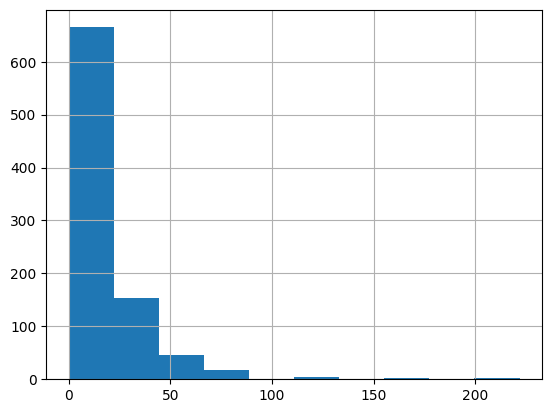

In [ ]:
# Now we examine Fare and Ticket. We are trying to examine people that were travelling in groups. 

# Ok plan:

# Calculate 'log individual fare' #check
# drop ticket column # check
# drop original fare columne # check
# Keep combined family_size column

ticket_counts = Titanic_train['Ticket'].value_counts()
group_size_by_ticket = Titanic_train['Ticket'].map(ticket_counts)

Titanic_train['Individual_Fare'] = Titanic_train['Fare'] / group_size_by_ticket

Titanic_train['Individual_Fare'].hist()

# We should log to deal with skew

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,Family,Sibsp_bins,Parch_bins,Family_bins,Cabin_group,Has_Cabin_Record,Individual_Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S,Mr,1,One,Zero,One,N/A,0,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C,Mrs/Mme,1,One,Zero,One,Upper Decks,1,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S,Miss/Mlle,0,Zero,Zero,Zero,N/A,0,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S,Mrs/Mme,1,One,Zero,One,Upper Decks,1,3.316003
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S,Mr,0,Zero,Zero,Zero,N/A,0,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,NaN,S,Other,0,Zero,Zero,Zero,N/A,0,2.639057
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,B42,S,Miss/Mlle,0,Zero,Zero,Zero,Upper Decks,1,3.433987
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,NaN,S,Miss/Mlle,3,One,Two or more,Three or more,N/A,0,2.543569
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C148,C,Mr,0,Zero,Zero,Zero,Upper Decks,1,3.433987


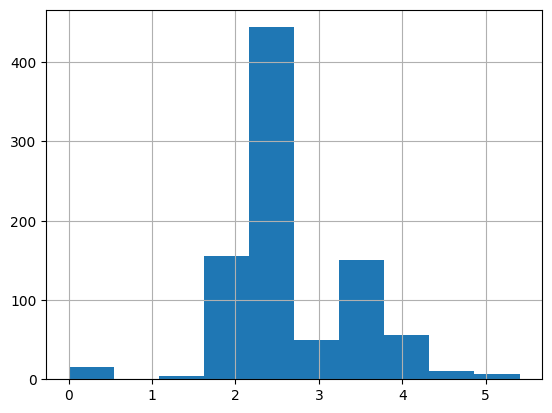

In [52]:
Titanic_train['Individual_Fare'] = np.log1p(Titanic_train['Fare'] / group_size_by_ticket)

# That looks much better. Log plus 1 away.
Titanic_train['Individual_Fare'].hist()

Titanic_train.drop(columns='Fare')
Titanic_train.drop(columns='Ticket')

<Axes: >

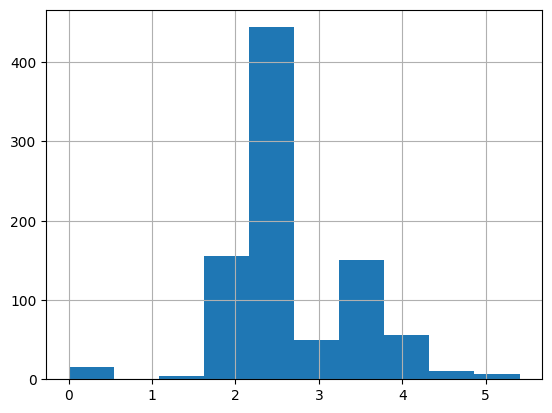

In [53]:
Titanic_train['Individual_Fare'].hist()

Text(0.5, 1.0, 'Distribution of Passenger Age on the Titanic')

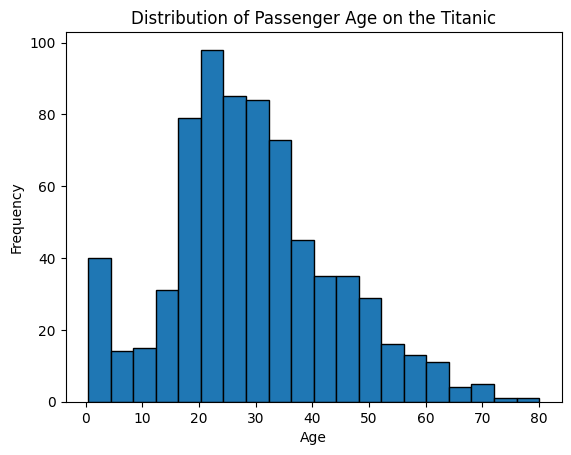

In [8]:
# Plot 
ax = Titanic_train[['Age']].plot(kind='hist', bins=20, edgecolor='black', legend=False)

# Add your labels quickly so you can get back to analyzing the distribution
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Passenger Age on the Titanic')

In [68]:
#print(str(Titanic_train['Pclass'].value_counts()))
Titanic_train.info()

Titanic_train.describe()

# Now I want to see the amount of distinct values, so we can see how to cluster this data.
list_of_distincts = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Cabin']

Titanic_train['Embarked'].value_counts()
#len(Titanic_train['Cabin'].value_counts())
#max(Titanic_train['Age'])
#Titanic_train[['Embarked']].mode


Titanic_train['Ticket']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object